<a href="https://colab.research.google.com/github/RaushanSingh-codes/UniFresh_AUnified-Food-Freshness-Classification-System/blob/Model/fressness_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kaggle

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"piyushsengar001","key":"096fdee09d4e7ae322ec4ac8ab73f20e"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d swoyam2609/fresh-and-stale-classification

Dataset URL: https://www.kaggle.com/datasets/swoyam2609/fresh-and-stale-classification
License(s): Community Data License Agreement - Permissive - Version 1.0
100% 2.84G/2.84G [00:31<00:00, 96.5MB/s]



In [7]:
!unzip fresh-and-stale-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: dataset/Train/rottencapsicum/WhatsApp Image 2020-11-07 at 11.43.17 PM.jpg_0_5372.jpg  
  inflating: dataset/Train/rottencapsicum/WhatsApp Image 2020-11-07 at 11.43.17 PM.jpg_0_54.jpg  
  inflating: dataset/Train/rottencapsicum/WhatsApp Image 2020-11-07 at 11.43.17 PM.jpg_0_6186.jpg  
  inflating: dataset/Train/rottencapsicum/WhatsApp Image 2020-11-07 at 11.43.17 PM.jpg_0_6285.jpg  
  inflating: dataset/Train/rottencapsicum/WhatsApp Image 2020-11-07 at 11.43.17 PM.jpg_0_6551.jpg  
  inflating: dataset/Train/rottencapsicum/WhatsApp Image 2020-11-07 at 11.43.17 PM.jpg_0_6565.jpg  
  inflating: dataset/Train/rottencapsicum/WhatsApp Image 2020-11-07 at 11.43.17 PM.jpg_0_6985.jpg  
  inflating: dataset/Train/rottencapsicum/WhatsApp Image 2020-11-07 at 11.43.17 PM.jpg_0_7173.jpg  
  inflating: dataset/Train/rottencapsicum/WhatsApp Image 2020-11-07 at 11.43.17 PM.jpg_0_7306.jpg  
  inflating: dataset/Train/rottencapsicum/WhatsApp 

In [8]:
!ls

dataset				    kaggle.json  sample_data
fresh-and-stale-classification.zip  newdataset


In [9]:
!ls dataset

Test  Train


In [10]:
!ls dataset/Train

freshapples	  freshokra	rottenbanana	   rottenoranges
freshbanana	  freshoranges	rottenbittergroud  rottenpotato
freshbittergroud  freshpotato	rottencapsicum	   rottentomato
freshcapsicum	  freshtomato	rottencucumber
freshcucumber	  rottenapples	rottenokra


In [11]:
import os
import shutil

base_path = "/content/dataset"
new_base = "/content/newdataset"

for split in ["Train", "Test"]:
    os.makedirs(f"{new_base}/{split}/fresh", exist_ok=True)
    os.makedirs(f"{new_base}/{split}/spoiled", exist_ok=True)

    split_path = os.path.join(base_path, split)

    for folder in os.listdir(split_path):
        folder_path = os.path.join(split_path, folder)

        if "fresh" in folder.lower():
            for img in os.listdir(folder_path):
                shutil.copy(
                    os.path.join(folder_path, img),
                    f"{new_base}/{split}/fresh"
                )

        elif "rotten" in folder.lower():
            for img in os.listdir(folder_path):
                shutil.copy(
                    os.path.join(folder_path, img),
                    f"{new_base}/{split}/spoiled"
                )

In [12]:
!ls newdataset/Train

fresh  spoiled


In [13]:
!ls newdataset/Test

fresh  spoiled


In [15]:
import os

print("Train Fresh:", len(os.listdir('newdataset/Train/fresh')))
print("Train Spoiled:", len(os.listdir('newdataset/Train/spoiled')))
print("Test Fresh:", len(os.listdir('newdataset/Test/fresh')))
print("Test Spoiled:", len(os.listdir('newdataset/Test/spoiled')))

Train Fresh: 11200
Train Spoiled: 12419
Test Fresh: 3245
Test Spoiled: 3493


In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models


In [17]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 8

In [18]:
!ls /content/newdataset

Test  Train


In [19]:
!ls /content/newdataset/Train

fresh  spoiled


In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/newdataset/Train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    '/content/newdataset/Test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 23619 images belonging to 2 classes.
Found 6738 images belonging to 2 classes.


In [21]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/final_food_freshness.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [23]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[checkpoint]
)

# Save final model
model.save("final_food_freshness.keras")

# Download model
from google.colab import files
files.download("final_food_freshness.keras")

Epoch 1/8
739/739 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8985 - loss: 0.2359
Epoch 1: val_accuracy improved from None to 0.94182, saving model to /content/drive/MyDrive/final_food_freshness.keras

Epoch 1: finished saving model to /content/drive/MyDrive/final_food_freshness.keras
739/739 ━━━━━━━━━━━━━━━━━━━━ 1747s 2s/step - accuracy: 0.9328 - loss: 0.1676 - val_accuracy: 0.9418 - val_loss: 0.1472
Epoch 2/8
739/739 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9611 - loss: 0.1031
Epoch 2: val_accuracy improved from 0.94182 to 0.96201, saving model to /content/drive/MyDrive/final_food_freshness.keras

Epoch 2: finished saving model to /content/drive/MyDrive/final_food_freshness.keras
739/739 ━━━━━━━━━━━━━━━━━━━━ 1720s 2s/step - accuracy: 0.9630 - loss: 0.0978 - val_accuracy: 0.9620 - val_loss: 0.0924
Epoch 3/8
739/739 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9712 - loss: 0.0749
Epoch 3: val_accuracy improved from 0.96201 to 0.97165, saving model to /content/drive/MyDrive/fina

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files
uploaded = files.upload()

Saving final_food_freshness.keras to final_food_freshness.keras


In [27]:
import tensorflow as tf
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/final_food_freshness.keras'
)

In [28]:
loss, acc = model.evaluate(test_generator)
print("Final Accuracy:", acc)

211/211 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.9837 - loss: 0.0443
Final Accuracy: 0.9836747050285339


In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

test_generator.reset()
preds = model.predict(test_generator)
pred_labels = (preds > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, pred_labels)
print(cm)

print(classification_report(test_generator.classes, pred_labels))

211/211 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step
[[3171   74]
 [  36 3457]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3245
           1       0.98      0.99      0.98      3493

    accuracy                           0.98      6738
   macro avg       0.98      0.98      0.98      6738
weighted avg       0.98      0.98      0.98      6738



In [30]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-03-04 114615.png to Screenshot 2026-03-04 114615.png


In [31]:
from tensorflow.keras.preprocessing import image
import numpy as np

IMG_SIZE = (224,224)

img = image.load_img('Screenshot 2026-03-04 114615.png', target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [32]:
prediction = model.predict(img_array)[0][0]

print("Raw Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Raw Prediction: 0.9999867


In [33]:
fresh_percent = (1 - prediction) * 100
spoiled_percent = prediction * 100

if prediction < 0.5:
    print("Fresh")
else:
    print("Spoiled")

print("Freshness:", round(fresh_percent,2), "%")
print("Spoiled:", round(spoiled_percent,2), "%")

Spoiled
Freshness: 0.0 %
Spoiled: 100.0 %


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

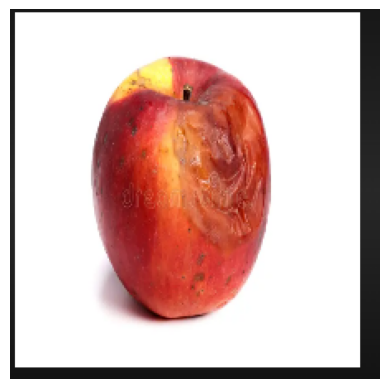

In [34]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")

In [35]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-03-04 114556.png to Screenshot 2026-03-04 114556.png


In [36]:
from tensorflow.keras.preprocessing import image
import numpy as np

IMG_SIZE = (224,224)

img = image.load_img('Screenshot 2026-03-04 114556.png', target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)[0][0]

print("Raw Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Raw Prediction: 0.012906172


In [37]:
fresh_percent = (1 - prediction) * 100
spoiled_percent = prediction * 100

if prediction < 0.5:
    print("Fresh")
else:
    print("Spoiled")

print("Freshness:", round(fresh_percent,2), "%")
print("Spoiled:", round(spoiled_percent,2), "%")

Fresh
Freshness: 98.71 %
Spoiled: 1.29 %


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

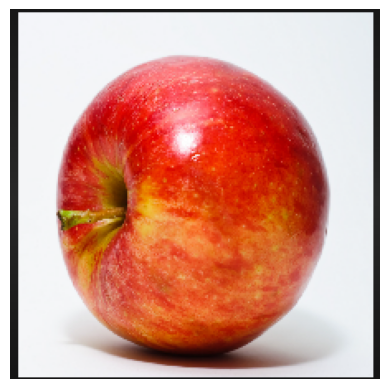

In [38]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")